In [1]:
#מטרת הפרוקט היא לנתח את הביצועים של השחקנים בטורנירים 
#שאלות יהיו מי השחקנים עם הזכיות הכי גבוהות ? איזה שנים היו הכו רןןחיות? מאיזו מדינה באים השחקנים הכי מורווחים?
# כלים שאני אשתמש הם pandas לנתוח ניתונים ; seaborn, matplotlib לוויזואליזציה

import pandas as pd

In [2]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=-PC\\SQLEXPRESS;"
    "DATABASE=POKER;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;")

In [3]:
Player = pd.read_sql('select * from Player' , conn)
Results = pd.read_sql('select * from results' , conn)
Tournament = pd.read_sql('select * from tournament' , conn)


C:\Users\User\AppData\Local\Temp\ipykernel_36296\3899344351.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Player = pd.read_sql('select * from Player' , conn)
C:\Users\User\AppData\Local\Temp\ipykernel_36296\3899344351.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Results = pd.read_sql('select * from results' , conn)
C:\Users\User\AppData\Local\Temp\ipykernel_36296\3899344351.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Tournament = pd.read_sql('select * from tournament' , conn)


In [4]:
Player.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           39 non-null     int64  
 1   Name         39 non-null     str    
 2   Nationality  39 non-null     str    
 3   Bracelets    39 non-null     int64  
 4   TotalWin     39 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 1.7 KB


In [5]:
Results.info()

<class 'pandas.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             119 non-null    int64  
 1   Position       119 non-null    int64  
 2   Win            119 non-null    float64
 3   Player_Id      119 non-null    int64  
 4   Tournament_Id  119 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 4.8 KB


In [6]:
Tournament.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               54 non-null     int64  
 1   Country          54 non-null     str    
 2   Num_Of_Players   54 non-null     int64  
 3   Buy_In           54 non-null     float64
 4   Prize_Pool       54 non-null     float64
 5   Edition_Year     54 non-null     int64  
 6   Tournament_Name  54 non-null     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 3.1 KB


In [7]:
Player.head()

,ID,Name,Nationality,Bracelets,TotalWin
0,1332,Benny Glaser,UK,8,7000000.0
1,1383,Billy Baxter,USA,7,8000000.0
2,2184,Chris Ferguson,USA,6,9500000.0
3,3696,Doyle Brunson,USA,10,6100000.0
4,5808,Jay Heimowitz,USA,6,4875000.0


In [8]:
Results.head()

,ID,Position,Win,Player_Id,Tournament_Id
0,5129823,180,42285.0,6543,20097
1,5130217,1271,15000.0,5883,20086
2,5130371,27,45000.0,13904,20114
3,5130531,11,526778.0,13911,20127
4,5130734,319,32871.0,11980,20117


In [9]:
Tournament.head()

,ID,Country,Num_Of_Players,Buy_In,Prize_Pool,Edition_Year,Tournament_Name
0,20084,USA,178,10000.0,1795100.0,1989,WSOP Main Event
1,20085,USA,8773,10000.0,82512162.0,2006,WSOP Main Event
2,20086,USA,8569,10000.0,80548604.0,2019,WSOP Main Event
3,20087,USA,312,10000.0,3120000.0,1997,WSOP Main Event
4,20088,USA,8,10000.0,80000.0,1972,WSOP Main Event


In [10]:
df = Player.merge(Results , left_on = 'ID'  , right_on =  'Player_Id').merge(Tournament , left_on = 'Tournament_Id' , right_on = 'ID')

In [11]:
df.columns

Index(['ID_x', 'Name', 'Nationality', 'Bracelets', 'TotalWin', 'ID_y',
       'Position', 'Win', 'Player_Id', 'Tournament_Id', 'ID', 'Country',
       'Num_Of_Players', 'Buy_In', 'Prize_Pool', 'Edition_Year',
       'Tournament_Name'],
      dtype='str')

In [12]:
df = df.drop(columns=["ID_x", "ID_y", "ID"])

In [13]:
df.head()  
# כאן רואים את מבנה הנתונים:
# שם השחקן, אזרחות, מספר צמידים,
# סך הזכיות בקריירה,
# המיקום בטורניר מסוים,
# סכום הזכייה בטורניר,
# המדינה שבה התקיים הטורניר,
# השנה ושם הטורניר

,Name,Nationality,Bracelets,TotalWin,Position,Win,Player_Id,Tournament_Id,Country,Num_Of_Players,Buy_In,Prize_Pool,Edition_Year,Tournament_Name
0,Benny Glaser,UK,8,7000000.0,960,17000.0,1332,20099,USA,8663,10000.0,80782475.0,2022,WSOP Main Event
1,Billy Baxter,USA,7,8000000.0,37,20000.0,1383,20132,USA,613,10000.0,6130000.0,2001,WSOP Main Event
2,Billy Baxter,USA,7,8000000.0,136,58570.0,1383,20135,USA,6358,10000.0,59784954.0,2007,WSOP Main Event
3,Billy Baxter,USA,7,8000000.0,22,21200.0,1383,20087,USA,312,10000.0,3120000.0,1997,WSOP Main Event
4,Billy Baxter,USA,7,8000000.0,733,17500.0,1383,20137,USA,6650,10000.0,62011250.0,2021,WSOP Main Event


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             119 non-null    str    
 1   Nationality      119 non-null    str    
 2   Bracelets        119 non-null    int64  
 3   TotalWin         119 non-null    float64
 4   Position         119 non-null    int64  
 5   Win              119 non-null    float64
 6   Player_Id        119 non-null    int64  
 7   Tournament_Id    119 non-null    int64  
 8   Country          119 non-null    str    
 9   Num_Of_Players   119 non-null    int64  
 10  Buy_In           119 non-null    float64
 11  Prize_Pool       119 non-null    float64
 12  Edition_Year     119 non-null    int64  
 13  Tournament_Name  119 non-null    str    
dtypes: float64(4), int64(6), str(4)
memory usage: 13.1 KB


In [15]:
df.describe()

#  מהסטטיסטיקות ניתן לראות כמה דברים מעניינים
# רוב הזכיות בטורנירים אינן גבוהות מאוד אבל יש מספר קטן של זכיות ענק שמעלות את הממוצע
# ניתן לראות פער גדול בין הממוצע לבין החציון בעמודת הזכיות
# הנתונים כוללים טורנירים משנת 1971 עד 2025 ולכן אפשר לנתח מגמות לאורך שנים
# מספר השחקנים בטורנירים משתנה מאוד יש טורנירים קטנים ויש טורנירים עם אלפי משתתפים
# דמי הכניסה לטורנירים דומים יחסית ונעים בין 5000 ל 10000

,Bracelets,TotalWin,Position,Win,Player_Id,Tournament_Id,Num_Of_Players,Buy_In,Prize_Pool,Edition_Year
count,119.000000,1.190000e+02,119.000000,1.190000e+02,119.000000,119.000000,119.000000,119.000000,1.190000e+02,119.000000
mean,7.033613,3.548083e+07,267.386555,2.173682e+05,9951.243697,20109.210084,5008.663866,9957.983193,4.696356e+07,2006.411765
std,4.428208,2.909373e+07,331.400984,9.542849e+05,4343.421306,15.529564,3687.263542,458.349249,3.441281e+07,14.374183
min,0.000000,5.600000e+05,1.000000,0.000000e+00,1332.000000,20084.000000,6.000000,5000.000000,3.000000e+04,1971.000000
25%,5.000000,8.000000e+06,11.000000,2.356800e+04,6543.000000,20099.000000,312.000000,10000.000000,3.120000e+06,1997.000000
50%,7.000000,2.360000e+07,109.000000,3.500000e+04,11980.000000,20105.000000,6494.000000,10000.000000,6.104492e+07,2010.000000
75%,10.000000,5.760870e+07,459.500000,7.785000e+04,13911.000000,20124.000000,7319.000000,10000.000000,6.879906e+07,2017.500000
max,17.000000,8.792718e+07,1468.000000,1.000000e+07,13923.000000,20137.000000,10112.000000,10000.000000,9.404160e+07,2025.000000


In [16]:
df.isnull().sum() 
# לא חסרים ערכים אין שורות למחוק
# אין צורך בלהחליף את ה 'edition_year' ל datetime כי זה לא תאריך אלה רק מספר שנה

Name               0
Nationality        0
Bracelets          0
TotalWin           0
Position           0
Win                0
Player_Id          0
Tournament_Id      0
Country            0
Num_Of_Players     0
Buy_In             0
Prize_Pool         0
Edition_Year       0
Tournament_Name    0
dtype: int64

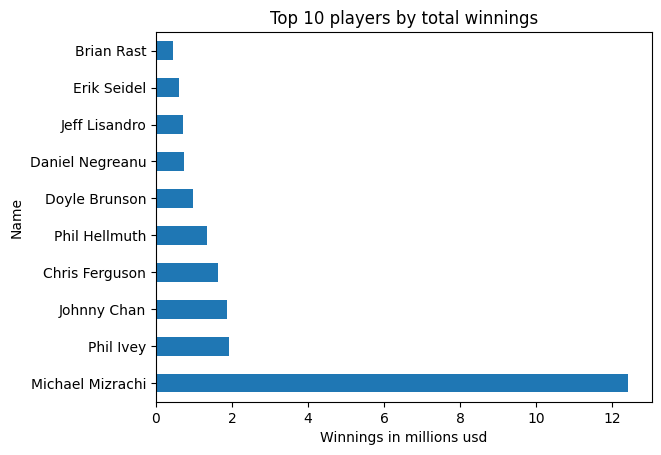

In [17]:
import matplotlib.pyplot as plt

top_players = df.groupby('Name')['Win'].sum().sort_values(ascending=False).head(10) / 1000000

top_players.plot(kind='barh')

plt.ylabel('Name')
plt.xlabel('Winnings in millions usd')
plt.title('Top 10 players by total winnings')
plt.show()
#ניתן כאן לראות את ה10 שחקנים שהרוויחו הכי הרבה כסף במיליוני דולרים 
#הניתוח לפי שנים מבוסס על הנתונים הקיימים במסד הנתונים. יש שנים שבהן קיימות מעט רשומות ולכן הסכום מייצג רק חלק מהתוצאות 

<Axes: title={'center': 'Total winnings by year in millions usd'}, xlabel='Edition_Year'>

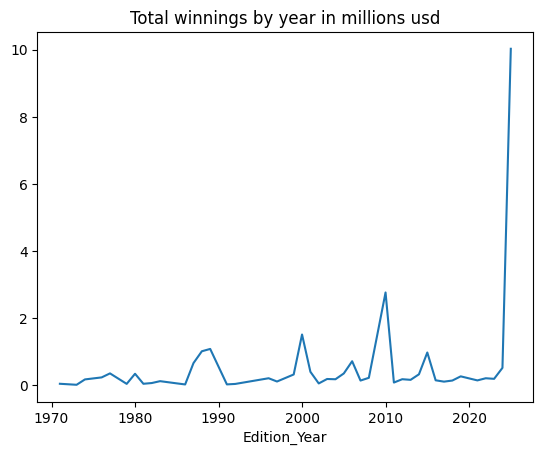

In [18]:
wins_by_year = df.groupby('Edition_Year')['Win'].sum()/1000000


wins_by_year.plot(kind='line', title='Total winnings by year in millions usd')
#אפשר לראות פה את ההתקדמות עם הזמן של הסכומים שמורווחים על ידי השחקנים
#הניתוח לפי שנים מבוסס על הנתונים הקיימים במסד הנתונים. יש שנים שבהן קיימות מעט רשומות ולכן הסכום מייצג רק חלק מהתוצאות 

<Axes: title={'center': 'Top countries by total winnings'}, xlabel='Nationality'>

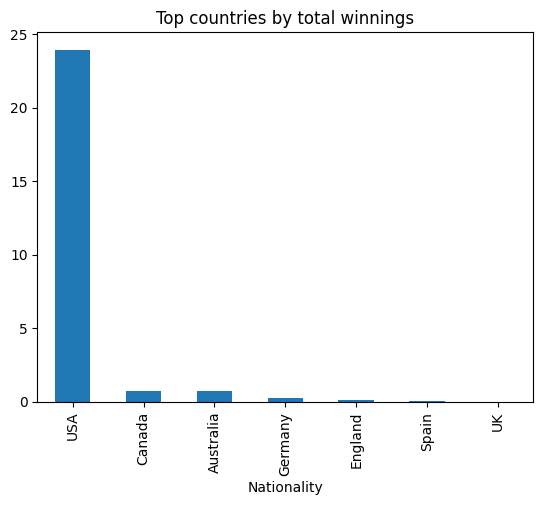

In [19]:
top_countries = df.groupby('Nationality')['Win'].sum().sort_values(ascending=False).head(10)/1000000

top_countries.plot(kind='bar', title='Top countries by total winnings')
#אפשר לראות פה את המדינות אשר באי השחקנים ם הכי הרבה זכיות
#הניתוח לפי שנים מבוסס על הנתונים הקיימים במסד הנתונים. יש שנים שבהן קיימות מעט רשומות ולכן הסכום מייצג רק חלק מהתוצאות 

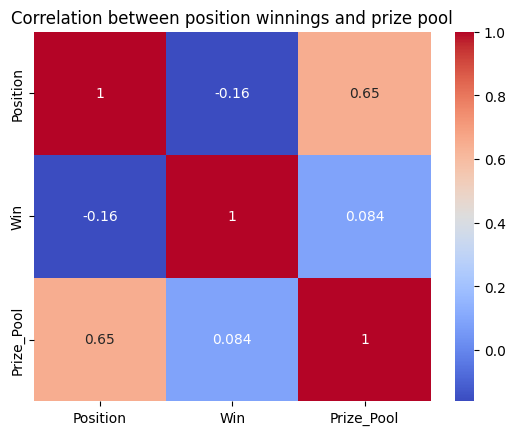

In [20]:
import seaborn as sns

data = df[['Position','Win','Prize_Pool']]

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation between position winnings and prize pool')
plt.show()
# קיים קשר שלילי חלש בין המיקום בטורניר לבין סכום הזכייה כלומר ככל שהמיקום טוב יותר הזכייה בדרך כלל גבוהה יותר
#  קיים קשר חיובי בין הפיזפול לבן מספר השחקנים שמרויחים כסף   
# אין קשר בין סכום הפרייזפול לבין הרווח ש השחקן
#הניתוח לפי שנים מבוסס על הנתונים הקיימים במסד הנתונים. יש שנים שבהן קיימות מעט רשומות ולכן הסכום מייצג רק חלק מהתוצאות 

<Axes: title={'center': 'Number of players vs Prize pool'}, xlabel='Num_Of_Players', ylabel='Prize_Pool'>

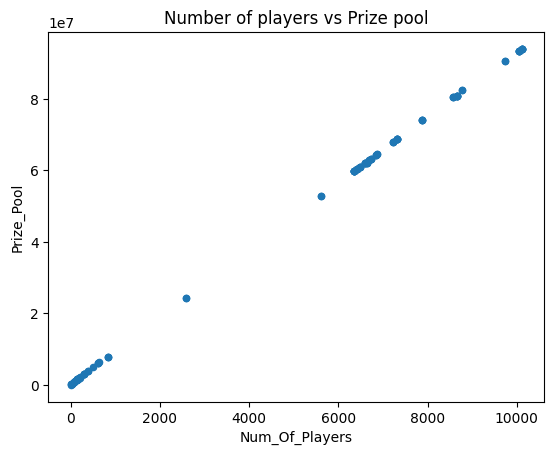

In [21]:
df.plot(kind='scatter', x='Num_Of_Players', y='Prize_Pool',
        title='Number of players vs Prize pool')
#אפשר לראות פה שכל עוד המספר של השחקנים גדל הזכייה תהיה יות גדולה
#הניתוח לפי שנים מבוסס על הנתונים הקיימים במסד הנתונים. יש שנים שבהן קיימות מעט רשומות ולכן הסכום מייצג רק חלק מהתוצאות 

In [22]:
# Conclusion
# מהניתוח ניתן לראות כי מספר קטן של שחקנים זוכה ברוב הכסף
# ארצות הברית מובילה במספר הזכיות בטורנירים
# ככל שמספר השחקנים בטורניר גדול יותר כך גובה סכום הפרסים בטורניר גדל
# בנוסף ניתן לראות קשר בין המיקום בטורניר לבין סכום הזכייה